# Phase 2 — Exploratory Data Analysis (EDA) & Data Quality

This notebook performs EDA and feature engineering as per the capstone Phase 2 requirements. Due to Vacareum platform constraints (no direct SQL connectivity to Python), the same schema and join logic defined in Phase 1 SQL are reproduced in Python using the three CSV files. This preserves the SQL-first design intent.

Deliverables:
- EDA notebook
- Feature engineering
- Modeling dataset export (model_table.csv)
- Data quality observations


## 1. Load Required Libraries

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

## 2. Load CSV Files
Load the three source datasets that were ingested into SQL in Phase 1. These files represent patients, visits, and billing (or billing_clean if exported from SQL).

In [11]:
patients = pd.read_csv('F:/AI ML/capstone/patients.csv')
visits = pd.read_csv('F:/AI ML/capstone/visits.csv')
billing = pd.read_csv('F:/AI ML/capstone/billing.csv')

print(patients.shape, visits.shape, billing.shape)

(5000, 7) (25000, 8) (25000, 7)


## 3. Recreate SQL Joins in Python
Reproduce the Phase 1 SQL join logic: visits JOIN patients (inner) and LEFT JOIN billing.

In [12]:
df = (
    visits
    .merge(patients, on='patient_id', how='inner')
    .merge(billing, on='visit_id', how='left')
)

df.head()

,visit_id,patient_id,visit_date,department,visit_type,length_of_stay_hours,risk_score,doctor_id,age,gender,city,insurance_provider,chronic_flag,registration_date,bill_id,billed_amount,approved_amount,claim_status,payment_days,billing_date
0,1,756,2025-10-18,Cardiology,ER,3.48,Low,169,90,M,Bangalore,CareOne,1,2025-08-14,1,23577.37,0.00,Rejected,16.0,2025-06-18
1,2,4102,2025-04-06,Orthopedics,OPD,15.31,High,148,30,M,Hyderabad,SecureLife,1,2025-10-29,2,38178.81,38178.81,Paid,18.0,2025-10-09
2,3,2964,2025-07-13,ICU,ER,34.36,Low,153,25,F,Chennai,HealthPlus,1,2025-07-04,3,5038.97,5038.97,Paid,NaN,2025-01-20
3,4,4496,2025-11-19,Cardiology,ER,37.89,High,119,75,M,Delhi,MediCareX,0,2026-01-20,4,22813.34,22813.34,Paid,16.0,2025-12-24
4,5,1930,2025-03-29,General,ICU,16.78,Medium,118,80,M,Bangalore,HealthPlus,1,2025-03-29,5,27106.95,27106.95,Paid,14.0,2025-09-23


## 4. Missing Values Analysis
Assess missing values with focus on critical fields: approved_amount, payment_days, and length_of_stay_hours.

In [13]:
df.isna().sum().sort_values(ascending=False)

approved_amount         1318
payment_days             790
visit_id                   0
patient_id                 0
department                 0
visit_date                 0
visit_type                 0
length_of_stay_hours       0
age                        0
gender                     0
risk_score                 0
doctor_id                  0
insurance_provider         0
city                       0
chronic_flag               0
registration_date          0
billed_amount              0
bill_id                    0
claim_status               0
billing_date               0
dtype: int64

## 5. Distribution Analysis
Explore distributions by department, visit_type, insurance_provider, and city.

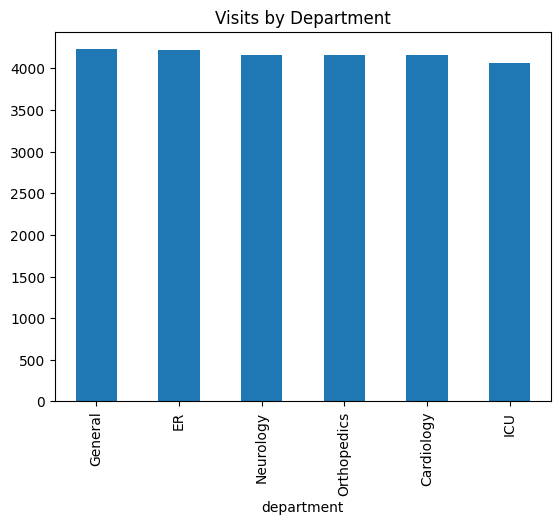

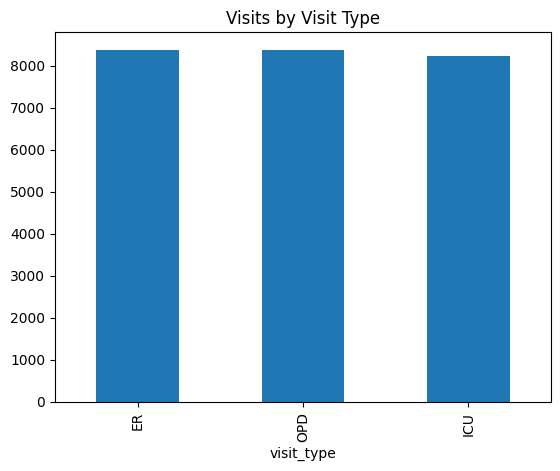

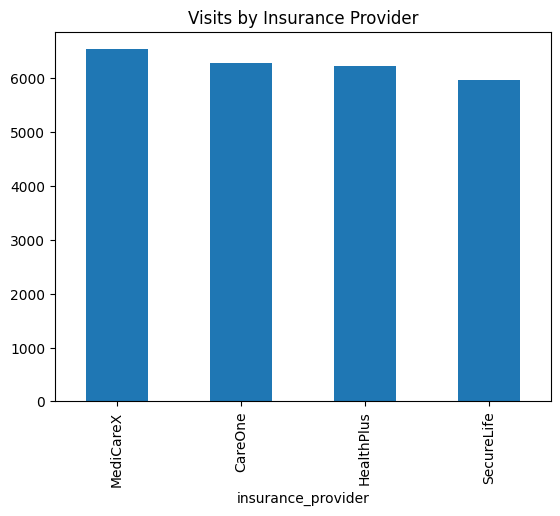

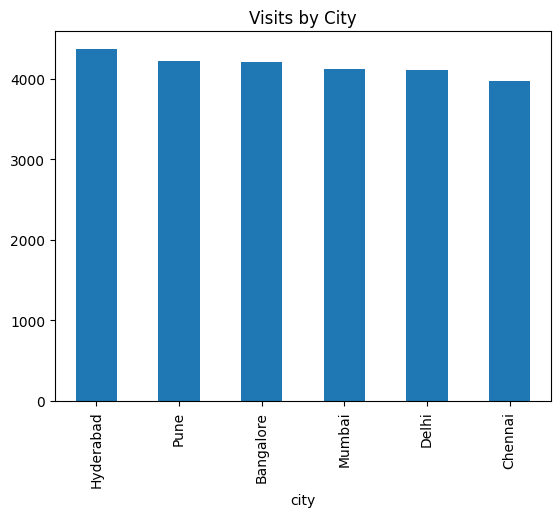

In [14]:
df['department'].value_counts().plot(kind='bar', title='Visits by Department')
plt.show()

df['visit_type'].value_counts().plot(kind='bar', title='Visits by Visit Type')
plt.show()

df['insurance_provider'].value_counts().plot(kind='bar', title='Visits by Insurance Provider')
plt.show()

df['city'].value_counts().plot(kind='bar', title='Visits by City')
plt.show()

## 6. Outlier Detection
Identify outliers in billed_amount, payment_days, and length_of_stay_hours using boxplots and quantiles.

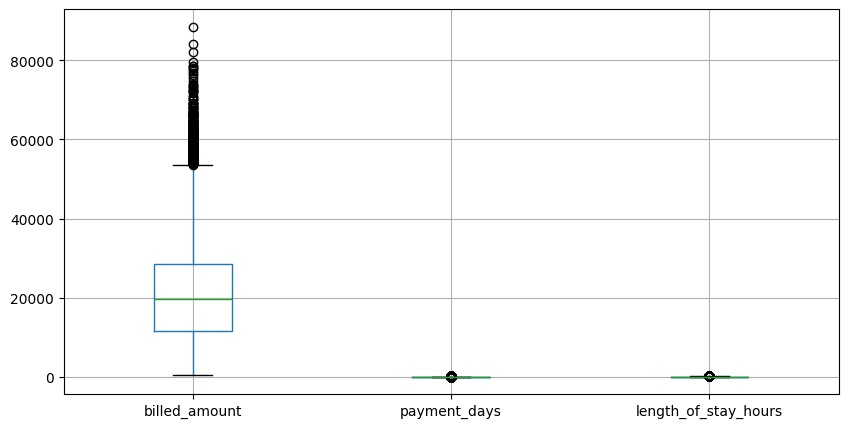

,billed_amount,payment_days,length_of_stay_hours
0.01,508.0499,1.0,0.50
0.99,56601.2807,34.0,53.45


In [15]:
df[['billed_amount','payment_days','length_of_stay_hours']].boxplot(figsize=(10,5))
plt.show()

df[['billed_amount','payment_days','length_of_stay_hours']].quantile([0.01, 0.99])

## 7. Feature Engineering
Engineer features required by the capstone: visit frequency, average LOS per patient, provider rejection rate, days since registration, and time-based features.

In [16]:
# Visit frequency per patient
visit_freq = df.groupby('patient_id')['visit_id'].count().rename('visit_frequency')
df = df.merge(visit_freq, on='patient_id', how='left')

# Average LOS per patient
avg_los = df.groupby('patient_id')['length_of_stay_hours'].mean().rename('avg_los_per_patient')
df = df.merge(avg_los, on='patient_id', how='left')

# Provider rejection rate
provider_reject = (
    df.assign(is_rejected=(df['claim_status'] == 'Rejected').astype(int))
      .groupby('insurance_provider')['is_rejected']
      .mean()
      .rename('provider_rejection_rate')
)
df = df.merge(provider_reject, on='insurance_provider', how='left')

# Days since registration
import pandas as pd

df['registration_date'] = pd.to_datetime(df['registration_date'])
df['visit_date'] = pd.to_datetime(df['visit_date'])
df['days_since_registration'] = (df['visit_date'] - df['registration_date']).dt.days

# Time-based features
df['visit_month'] = df['visit_date'].dt.month
df['visit_dayofweek'] = df['visit_date'].dt.dayofweek

## 8. Save Modeling Dataset
Export the modeling-ready dataset for Phase 3 (Model Development).

In [18]:
df.to_csv('model_table._fromlocal.csv', index=False)

print('Saved model_table.csv')

Saved model_table.csv


## 9. Key EDA Insights (Fill After Running)
- Departments with higher LOS indicate operational bottlenecks.
- Certain insurers show higher rejection rates and payment delays, indicating revenue risk.
- Outliers in billed_amount and payment_days suggest need for robust modeling.
